# 04 — Baseline: Dummy Classifier y Logistic Regression

Este notebook establece dos referencias antes de comenzar Feature Engineering:

1. un `DummyClassifier`, que representa el piso sin aprendizaje real;
2. una regresión logística sencilla sobre el conjunto original depurado.

El baseline respeta las exclusiones por leakage y disponibilidad temporal acordadas en Feature Analysis, pero no incorpora todavía `TotalGuests`, `TotalNights`, `IsDomestic`, interacciones ni otras features nuevas.

## Estrategia de validación

Se reservan las observaciones de 2017 como holdout temporal y se utilizan 2015–2016 para entrenamiento y selección de hiperparámetros. Como 2017 sólo contiene datos hasta agosto, esta partición mide generalización al período posterior observado, no el desempeño sobre un año calendario completo.

Dentro del conjunto de desarrollo se utiliza `StratifiedGroupKFold`. Los grupos se forman a partir de combinaciones idénticas de predictores, evitando que repeticiones exactas aparezcan a la vez en entrenamiento y validación interna. El holdout de 2017 no se utiliza para seleccionar hiperparámetros.

In [12]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)

In [13]:
def find_project_root(start_path=None):
    """Busca la raíz del repositorio a partir del directorio actual."""
    start = Path(start_path or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "src").is_dir():
            return candidate
    return None

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontró la raíz local del proyecto.")

project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [14]:
from src.config import RANDOM_STATE, RAW_DATA_DIR, TARGET_COL
from src.data import (
    combine_hotel_datasets,
    load_csv_with_fallback,
    make_temporal_holdout_split,
    normalize_text_values,
)
from src.evaluation import (
    evaluate_binary_classifier,
    get_grid_results,
    get_stratified_group_cross_validation,
    run_grid_search,
)
from src.features import (
    BASE_COLUMNS_TO_EXCLUDE,
    build_base_feature_set,
    get_feature_types,
    make_exact_feature_groups,
)
from src.plots import plot_confusion_matrix
from src.preprocessing import build_tabular_preprocessor

## Carga e integración de los datos

Se priorizan los archivos locales y se utilizan las URLs de GitHub como alternativa. La integración y normalización reutilizan las mismas funciones que el EDA.

In [15]:
H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"

h1_df = load_csv_with_fallback(RAW_DATA_DIR / "H1.csv", H1_URL)
h2_df = load_csv_with_fallback(RAW_DATA_DIR / "H2.csv", H2_URL)
bookings_df = combine_hotel_datasets(h1_df, h2_df)
bookings_df = normalize_text_values(bookings_df)

print(f"Dataset integrado: {bookings_df.shape[0]:,} filas y {bookings_df.shape[1]} columnas.")

Dataset integrado: 119,390 filas y 32 columnas.


## Conjunto base depurado

Se aplican solamente las decisiones imprescindibles de Feature Analysis: exclusión de variables no disponibles y reemplazo de los identificadores `Agent` y `Company` por `HasAgent` y `HasCompany`. No se crean todavía variables de Feature Engineering.

In [16]:
X, y = build_base_feature_set(bookings_df)
numeric_features, categorical_features = get_feature_types(X)

feature_summary = pd.DataFrame({
    "group": ["Numeric/binary", "Categorical", "Excluded"],
    "count": [len(numeric_features), len(categorical_features), len(BASE_COLUMNS_TO_EXCLUDE)],
    "columns": [numeric_features, categorical_features, list(BASE_COLUMNS_TO_EXCLUDE)],
})
display(feature_summary)
display(X.isna().sum().loc[lambda values: values.gt(0)].sort_values(ascending=False))

,group,count,columns
0,Numeric/binary,17,"[LeadTime, ArrivalDateYear, ArrivalDateWeekNum..."
1,Categorical,8,"[HotelType, ArrivalDateMonth, Meal, Country, M..."
2,Excluded,8,"[ReservationStatus, ReservationStatusDate, Ass..."


Country     488
Children      4
dtype: int64

## Holdout temporal y grupos de validación interna

In [17]:
X_train, X_validation, y_train, y_validation = make_temporal_holdout_split(
    X,
    y,
    period_values=X["ArrivalDateYear"],
    validation_period=2017,
)
train_groups = make_exact_feature_groups(X_train)

split_summary = pd.DataFrame({
    "subset": ["Development (2015-2016)", "Temporal holdout (2017 Jan-Aug)"],
    "rows": [len(X_train), len(X_validation)],
    "cancellation_rate": [y_train.mean(), y_validation.mean()],
    "unique_feature_groups": [train_groups.nunique(), make_exact_feature_groups(X_validation).nunique()],
})
split_summary["cancellation_percentage"] = split_summary["cancellation_rate"] * 100
display(split_summary.round(4))

,subset,rows,cancellation_rate,unique_feature_groups,cancellation_percentage
0,Development (2015-2016),78703,0.3619,52930,36.1854
1,Temporal holdout (2017 Jan-Aug),40687,0.3870,30694,38.6979


## Piso de referencia: Dummy Classifier

La estrategia `prior` devuelve la probabilidad observada de cada clase en desarrollo. Su ROC AUC esperado es 0,5; las métricas dependientes del umbral sólo describen su comportamiento con el corte convencional de 0,5.

In [18]:
dummy_model = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)
dummy_feature = ["ArrivalDateYear"]
dummy_model.fit(X_train[dummy_feature], y_train)
dummy_metrics = evaluate_binary_classifier(
    dummy_model, X_validation[dummy_feature], y_validation
)
display(pd.DataFrame([dummy_metrics], index=["Dummy prior"]).round(4))

,roc_auc,accuracy,precision,recall,f1,threshold
Dummy prior,0.5,0.613,0.0,0.0,0.0,0.5


## Pipeline de Logistic Regression

Las numéricas se imputan por mediana y se escalan. Las categóricas se imputan por moda y reciben One-Hot Encoding con categorías desconocidas ignoradas. Todo el preprocesamiento se ajusta dentro de cada fold para evitar leakage.

In [19]:
base_preprocessor = build_tabular_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    scale_numeric=True,
)

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", base_preprocessor),
    ("model", LogisticRegression(solver="liblinear", max_iter=2000, random_state=RANDOM_STATE)),
])

## Búsqueda ligera de hiperparámetros

La grilla es deliberadamente pequeña: el objetivo es obtener una referencia, no optimizar exhaustivamente Logistic Regression antes de Feature Engineering. La selección utiliza exclusivamente los datos de 2015–2016.

In [20]:
param_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"],
}
group_cv = get_stratified_group_cross_validation(n_splits=5)

logistic_search = run_grid_search(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    X=X_train,
    y=y_train,
    scoring="roc_auc",
    cv=group_cv,
    groups=train_groups,
    n_jobs=-1,
)
grid_results = get_grid_results(logistic_search)
display(grid_results[["params", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]].round(4))
print(f"Mejores parámetros: {logistic_search.best_params_}")
print(f"Mejor ROC AUC CV: {logistic_search.best_score_:.4f}")

,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__C': 10.0, 'model__class_weight': 'bal...",0.8965,0.8925,0.0036,1
1,"{'model__C': 1.0, 'model__class_weight': 'bala...",0.8960,0.8924,0.0035,2
2,"{'model__C': 0.1, 'model__class_weight': 'bala...",0.8949,0.8920,0.0031,3
3,"{'model__C': 10.0, 'model__class_weight': None}",0.8957,0.8917,0.0036,4
4,"{'model__C': 1.0, 'model__class_weight': None}",0.8952,0.8917,0.0035,5
5,"{'model__C': 0.1, 'model__class_weight': None}",0.8941,0.8912,0.0031,6


Mejores parámetros: {'model__C': 10.0, 'model__class_weight': 'balanced'}
Mejor ROC AUC CV: 0.8925


## Evaluación única sobre el holdout temporal

El mejor pipeline según validación interna se evalúa una sola vez sobre 2017. ROC AUC es la métrica principal. Accuracy, precision, recall y F1 se muestran con umbral 0,5 como información secundaria; el ajuste del umbral se realizará más adelante con el análisis de negocio.

In [21]:
best_logistic_model = logistic_search.best_estimator_
logistic_metrics = evaluate_binary_classifier(
    best_logistic_model, X_validation, y_validation, threshold=0.5
)

baseline_comparison = pd.DataFrame([
    {"model": "Dummy prior", **dummy_metrics},
    {"model": "Logistic Regression base", **logistic_metrics},
]).set_index("model")
display(baseline_comparison.round(4))

,roc_auc,accuracy,precision,recall,f1,threshold
model,,,,,,
Dummy prior,0.5000,0.6130,0.0000,0.000,0.0000,0.5
Logistic Regression base,0.8422,0.7061,0.5798,0.874,0.6971,0.5


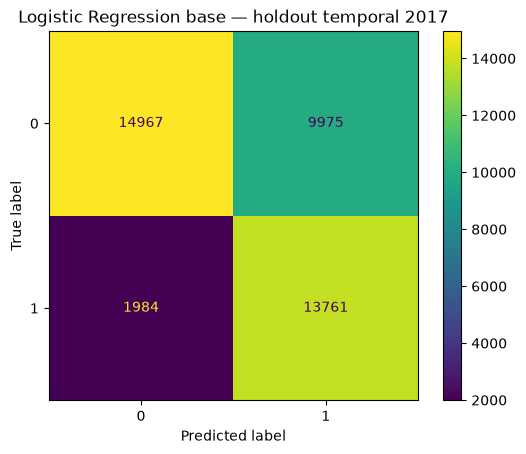

In [22]:
plot_confusion_matrix(
    best_logistic_model,
    X_validation,
    y_validation,
    threshold=0.5,
    title="Logistic Regression base — holdout temporal 2017",
)

## Conclusiones del baseline

El `DummyClassifier` obtiene ROC AUC 0,5 y accuracy 0,6130. Como asigna a todas las reservas la probabilidad de cancelación observada en desarrollo (0,3619), ninguna supera el umbral 0,5: predice siempre la clase mayoritaria y por eso precision, recall y F1 de la clase cancelación son cero. Este resultado muestra que accuracy por sí sola no es una referencia suficiente.

La regresión logística mejora el ROC AUC temporal hasta 0,8422. La búsqueda seleccionó `C=10` y `class_weight='balanced'`, con ROC AUC medio de 0,8925 y desviación 0,0036 en los folds agrupados. La baja dispersión indica estabilidad entre esos folds, pero la caída de aproximadamente 0,05 frente al holdout 2017 revela que la generalización temporal es más exigente que la validación interna sobre 2015–2016.

Con umbral 0,5, el modelo alcanza recall 0,8740 y precision 0,5798. Detecta 13.761 de las 15.745 cancelaciones, dejando 1.984 falsos negativos, pero también genera 9.975 falsos positivos. Este comportamiento es coherente con el balanceo de clases: prioriza recuperar cancelaciones a costa de intervenir sobre muchas reservas que finalmente no cancelan.

El umbral 0,5 no se considera todavía una decisión operativa. ROC AUC es la métrica principal para comparar modelos y el umbral se elegirá posteriormente según capacidad de intervención, costos y efectividad esperada de la acción. Este baseline será la referencia para medir el aporte de Feature Engineering y de modelos más flexibles.

# Evaluación operativa de cancelaciones críticas

El modelo fue entrenado para predecir cualquier cancelación, pero no todas tienen el mismo impacto operativo. Para evaluar su utilidad sin redefinir el target, se consideran críticas las reservas con estado final `No-Show` y las canceladas como máximo siete días antes de la llegada. Las columnas de estado y fecha se usan únicamente para evaluar el resultado futuro; nunca ingresan al modelo.

El límite de siete días es una hipótesis operativa inicial y deberá incluirse posteriormente en un análisis de sensibilidad.

In [23]:
LATE_CANCELLATION_DAYS = 7

business_validation = bookings_df.loc[X_validation.index, [
    "ReservationStatus", "ReservationStatusDate", "ADR",
    "ArrivalDateYear", "ArrivalDateMonth", "ArrivalDateDayOfMonth",
    "StaysInWeekendNights", "StaysInWeekNights",
]].copy()
business_validation["ActualCancellation"] = y_validation
business_validation["CancellationProbability"] = (
    best_logistic_model.predict_proba(X_validation)[:, 1]
)
business_validation["PredictedCancellation"] = (
    business_validation["CancellationProbability"] >= 0.5
).astype("int8")

arrival_month_number = pd.to_datetime(
    business_validation["ArrivalDateMonth"], format="%B"
).dt.month
business_validation["ArrivalDate"] = pd.to_datetime({
    "year": business_validation["ArrivalDateYear"],
    "month": arrival_month_number,
    "day": business_validation["ArrivalDateDayOfMonth"],
})
business_validation["StatusDate"] = pd.to_datetime(
    business_validation["ReservationStatusDate"]
)
business_validation["DaysBeforeArrival"] = (
    business_validation["ArrivalDate"] - business_validation["StatusDate"]
).dt.days

business_validation["IsNoShow"] = business_validation["ReservationStatus"].eq("No-Show")
business_validation["IsLateCancellation"] = (
    business_validation["ReservationStatus"].eq("Canceled")
    & business_validation["DaysBeforeArrival"].between(0, LATE_CANCELLATION_DAYS)
)
business_validation["IsCriticalCancellation"] = (
    business_validation["IsNoShow"] | business_validation["IsLateCancellation"]
)
business_validation["CriticalOutcome"] = np.select(
    [
        business_validation["IsCriticalCancellation"] & business_validation["PredictedCancellation"].eq(1),
        business_validation["IsCriticalCancellation"] & business_validation["PredictedCancellation"].eq(0),
        ~business_validation["IsCriticalCancellation"] & business_validation["PredictedCancellation"].eq(1),
    ],
    ["Critical detected", "Critical missed", "Non-critical intervention"],
    default="No critical event or intervention",
)

## Valor bruto estimado

El valor bruto se aproxima como `ADR × TotalNights`. Esto no representa una pérdida contable observada: no se dispone de pagos, penalizaciones, reventa de habitaciones ni costos evitados. El registro con `ADR = 5400` se excluye del cálculo económico porque es un único extremo claramente separado del resto y podría dominar el resultado. También se excluye el único ADR negativo. Los valores iguales a cero se conservan y aportan valor cero.

In [24]:
business_validation["TotalNights"] = (
    business_validation["StaysInWeekendNights"]
    + business_validation["StaysInWeekNights"]
)
business_validation["EconomicValueEligible"] = (
    business_validation["ADR"].ge(0) & business_validation["ADR"].ne(5400)
)
business_validation["EstimatedBookingValue"] = np.where(
    business_validation["EconomicValueEligible"],
    business_validation["ADR"] * business_validation["TotalNights"],
    np.nan,
)

excluded_economic_records = business_validation.loc[
    ~business_validation["EconomicValueEligible"],
    ["ADR", "TotalNights", "ReservationStatus", "IsCriticalCancellation"],
]
display(excluded_economic_records)

,ADR,TotalNights,ReservationStatus,IsCriticalCancellation
14969,-6.38,10,Check-Out,False


In [25]:
critical_event_summary = pd.DataFrame([
    {"metric": "No-shows", "value": business_validation["IsNoShow"].sum()},
    {"metric": "Late cancellations (0-7 days)", "value": business_validation["IsLateCancellation"].sum()},
    {"metric": "Critical events", "value": business_validation["IsCriticalCancellation"].sum()},
    {"metric": "Critical events detected", "value": (business_validation["IsCriticalCancellation"] & business_validation["PredictedCancellation"].eq(1)).sum()},
    {"metric": "Critical events missed", "value": (business_validation["IsCriticalCancellation"] & business_validation["PredictedCancellation"].eq(0)).sum()},
    {"metric": "Total interventions", "value": business_validation["PredictedCancellation"].sum()},
    {"metric": "Non-critical interventions", "value": (~business_validation["IsCriticalCancellation"] & business_validation["PredictedCancellation"].eq(1)).sum()},
])

critical_mask = business_validation["IsCriticalCancellation"]
detected_critical_mask = critical_mask & business_validation["PredictedCancellation"].eq(1)
missed_critical_mask = critical_mask & business_validation["PredictedCancellation"].eq(0)
economic_summary = pd.DataFrame([
    {"metric": "Estimated critical value without model", "value": business_validation.loc[critical_mask, "EstimatedBookingValue"].sum()},
    {"metric": "Estimated critical value detected", "value": business_validation.loc[detected_critical_mask, "EstimatedBookingValue"].sum()},
    {"metric": "Estimated critical value missed", "value": business_validation.loc[missed_critical_mask, "EstimatedBookingValue"].sum()},
])

critical_recall = detected_critical_mask.sum() / critical_mask.sum()
critical_value_capture = (
    economic_summary.loc[economic_summary["metric"].eq("Estimated critical value detected"), "value"].iloc[0]
    / economic_summary.loc[economic_summary["metric"].eq("Estimated critical value without model"), "value"].iloc[0]
)

display(critical_event_summary)
display(economic_summary.round(2))
print(f"Critical-event recall: {critical_recall:.4f}")
print(f"Critical-value capture: {critical_value_capture:.4f}")

,metric,value
0,No-shows,348
1,Late cancellations (0-7 days),1250
2,Critical events,1598
3,Critical events detected,1179
4,Critical events missed,419
5,Total interventions,23736
6,Non-critical interventions,22557


,metric,value
0,Estimated critical value without model,540098.62
1,Estimated critical value detected,419003.64
2,Estimated critical value missed,121094.98


Critical-event recall: 0.7378
Critical-value capture: 0.7758


El holdout contiene 1.598 eventos críticos: 348 `No-Show` y 1.250 cancelaciones entre cero y siete días antes de la llegada. El modelo detecta 1.179 y omite 419, alcanzando recall crítico 0,7378. Además, identifica el 77,58 % del valor bruto crítico estimado (419.003,64 de 540.098,62 unidades monetarias).

Esta cobertura requiere 23.736 intervenciones. Sólo 1.179, el 4,97 %, corresponden a eventos críticos; las restantes incluyen 12.582 cancelaciones tempranas correctamente predichas y 9.975 reservas que finalmente no cancelan. El resultado es coherente con un modelo entrenado para cancelaciones generales y muestra que un buen recall crítico no implica por sí solo una política operativamente eficiente.

El valor crítico detectado es una cota superior del beneficio potencial bajo el supuesto simplificado de que una cancelación crítica pierde todo el valor de la reserva y de que una intervención exitosa puede recuperarlo. El análisis final aplicará costos de intervención, efectividad y recuperación mediante escenarios; no afirmará que el valor bruto detectado constituye ahorro real.